In [50]:
!python -m pip install --upgrade pip

In [51]:
!pip install pandas matplotlib seaborn scikit-learn

In [52]:
import pandas as pd

In [53]:
# Veriyi yüklüyoruz
df = pd.read_csv("Big 5 European football leagues teams stats.csv")

In [54]:
# Veri setindeki toplam satır ve sütun sayısını görelim
print("Veri Seti Boyutu:", df.shape)

Veri Seti Boyutu: (1078, 28)


In [55]:
# Sütun isimlerini ve veri tiplerini inceleyelim
print("\n--- Veri Tipleri ve Eksik Değerler ---")
df.info()


--- Veri Tipleri ve Eksik Değerler ---
<class 'pandas.DataFrame'>
RangeIndex: 1078 entries, 0 to 1077
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   competition              1078 non-null   str    
 1   season                   1078 non-null   str    
 2   rank                     1078 non-null   int64  
 3   squad                    1078 non-null   str    
 4   games                    1078 non-null   int64  
 5   wins                     1078 non-null   int64  
 6   draws                    1078 non-null   int64  
 7   losses                   1078 non-null   int64  
 8   goals_for                1078 non-null   int64  
 9   goals_against            1078 non-null   int64  
 10  goal_diff                1078 non-null   int64  
 11  points                   1078 non-null   int64  
 12  notes                    450 non-null    str    
 13  players_used             1078 non-null   int64  


In [56]:
# Sadece La Liga'yı seçiyoruz
df_laliga = df[df['competition'] == 'La Liga']

In [57]:
# İlgilendiğimiz 9 sezonu bir liste halinde tanımlıyoruz
istenen_sezonlar = [
    '2010-2011', '2011-2012', '2012-2013', '2013-2014', 
    '2014-2015', '2015-2016', '2016-2017', '2017-2018', '2018-2019'
]

In [58]:
# Veriyi sadece bu sezonlar kalacak şekilde filtreliyoruz
df_proje = df_laliga[df_laliga['season'].isin(istenen_sezonlar)].copy()

In [59]:
print("Filtrelenmiş Proje Verisi Boyutu:", df_proje.shape)
df_proje.head()

Filtrelenmiş Proje Verisi Boyutu: (180, 28)


,competition,season,rank,squad,games,wins,draws,losses,goals_for,goals_against,...,cards_red,shots_on_target_against,saves,clean_sheets,shots_on_target,games_starts,games_complete,games_subs,unused_subs,points_per_match
858,La Liga,2010-2011,1,Barcelona,38,30,6,2,95,21,...,2.0,116,95,19,286,418,NaN,112,NaN,2.53
859,La Liga,2010-2011,2,Real Madrid,38,29,5,4,102,33,...,8.0,124,91,16,299,418,NaN,110,NaN,2.42
860,La Liga,2010-2011,3,Valencia,38,21,8,9,64,44,...,8.0,180,136,12,201,418,NaN,114,NaN,1.87
861,La Liga,2010-2011,4,Villarreal,38,18,8,12,54,44,...,5.0,174,130,13,207,418,NaN,105,NaN,1.63
862,La Liga,2010-2011,5,Sevilla,38,17,7,14,62,61,...,7.0,206,145,8,205,418,NaN,109,NaN,1.53


In [60]:
print("--- Temizlik Öncesi Eksik Veri Sayıları (İlk 10 Sütun) ---")
print(df_proje.isnull().sum().head(10))

--- Temizlik Öncesi Eksik Veri Sayıları (İlk 10 Sütun) ---
competition      0
season           0
rank             0
squad            0
games            0
wins             0
draws            0
losses           0
goals_for        0
goals_against    0
dtype: int64


In [61]:
# 1. Eksik Veri Temizliği (Drop): Çok fazla boşluk olan ve işimize yaramayacak 'notes' sütununu siliyoruz
if 'notes' in df_proje.columns:
    df_proje = df_proje.drop(columns=['notes'])

In [62]:
# 2. Eksik Veri Doldurma (Imputation): Sarı veya kırmızı kart verisi eksikse bunları 0 kabul ediyoruz
df_proje['cards_yellow'] = df_proje['cards_yellow'].fillna(0)
df_proje['cards_red'] = df_proje['cards_red'].fillna(0)

In [63]:
# 3. Tip Dönüşümü (Type Conversion): Kart sayıları ondalıklı (float) görünüyordu, onları tam sayıya (int) çeviriyoruz
df_proje['cards_yellow'] = df_proje['cards_yellow'].astype(int)
df_proje['cards_red'] = df_proje['cards_red'].astype(int)

In [64]:
print("\n--- Temizlik İşlemi Tamamlandı! ---")
print("Yeni Veri Seti Boyutu:", df_proje.shape)
print("Sarı Kart Sütunu Yeni Veri Tipi:", df_proje['cards_yellow'].dtype)


--- Temizlik İşlemi Tamamlandı! ---
Yeni Veri Seti Boyutu: (180, 27)
Sarı Kart Sütunu Yeni Veri Tipi: int64


In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
# Grafikleri notebook içinde düzgün görmek için satır içi ayarı
%matplotlib inline

In [67]:
# Temel İstatistiksel Özet
print("--- Veri Setinin Temel İstatistikleri ---")
display(df_proje[['goals_for', 'goals_against', 'points', 'shots_on_target', 'cards_yellow']].describe())

--- Veri Setinin Temel İstatistikleri ---


,goals_for,goals_against,points,shots_on_target,cards_yellow
count,180.000000,180.000000,180.000000,180.000000,180.000000
mean,52.250000,52.250000,52.477778,174.527778,66.816667
std,20.551849,13.125469,17.639929,44.453658,49.318991
min,22.000000,18.000000,20.000000,114.000000,0.000000
25%,40.000000,44.000000,42.000000,144.000000,0.000000
50%,46.000000,52.000000,48.000000,166.000000,88.500000
75%,58.000000,61.000000,60.000000,186.000000,105.000000
max,121.000000,94.000000,100.000000,318.000000,150.000000


<Axes: xlabel='shots_on_target', ylabel='goals_for'>

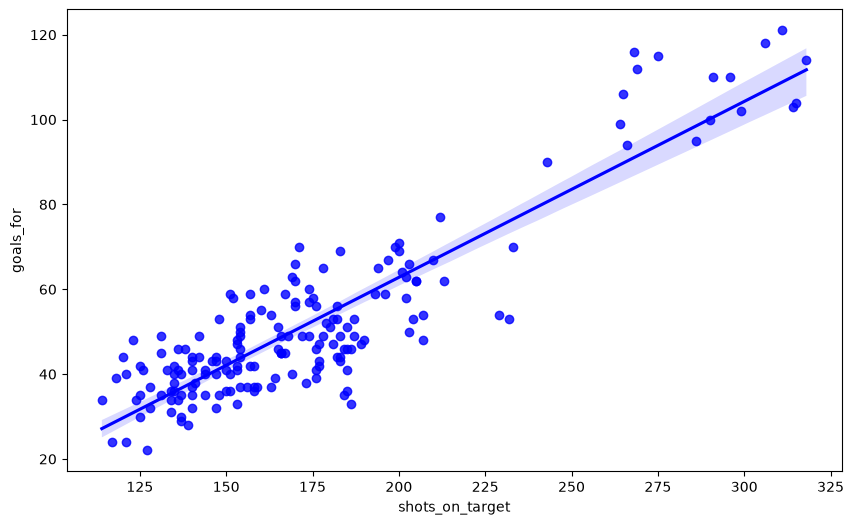

In [68]:
# Araştırma Sorusu 1: İsabetli şut sayısı ile atılan gol sayısı arasında nasıl bir ilişki var?
# Görselleştirme Türü 1: Dağılım Grafiği (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.regplot(data=df_proje, x='shots_on_target', y='goals_for', color='blue', marker='o')

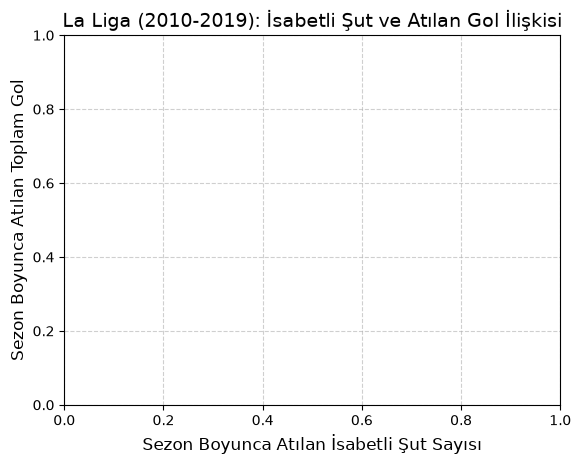

In [69]:
plt.title('La Liga (2010-2019): İsabetli Şut ve Atılan Gol İlişkisi', fontsize=14)
plt.xlabel('Sezon Boyunca Atılan İsabetli Şut Sayısı', fontsize=12)
plt.ylabel('Sezon Boyunca Atılan Toplam Gol', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

In [70]:
plt.show()

In [71]:
# Araştırma Sorusu 2: Bu 9 sezonluk dönemde toplamda en çok gol atan takımlar hangileri?
# Görselleştirme Türü 2: Çubuk Grafiği (Bar Chart)

# Takımlara göre gruplayıp 'goals_for' (atılan gol) sütununu toplayalım ve ilk 10'u seçelim
toplam_gol = df_proje.groupby('squad')['goals_for'].sum().sort_values(ascending=False).head(10)

<Axes: ylabel='squad'>

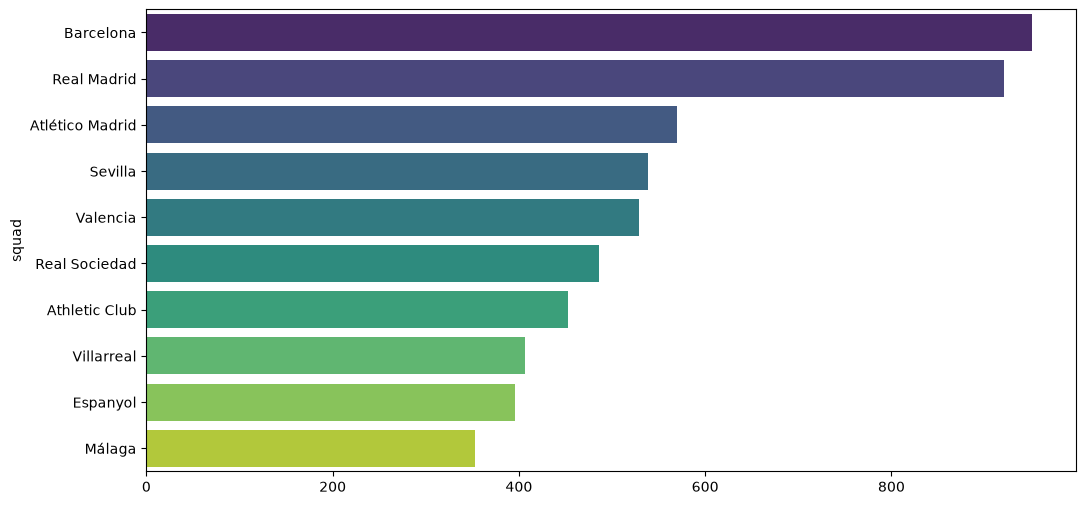

In [72]:
plt.figure(figsize=(12, 6))
sns.barplot(
    x=toplam_gol.values, 
    y=toplam_gol.index, 
    hue=toplam_gol.index, 
    palette='viridis', 
    legend=False
)

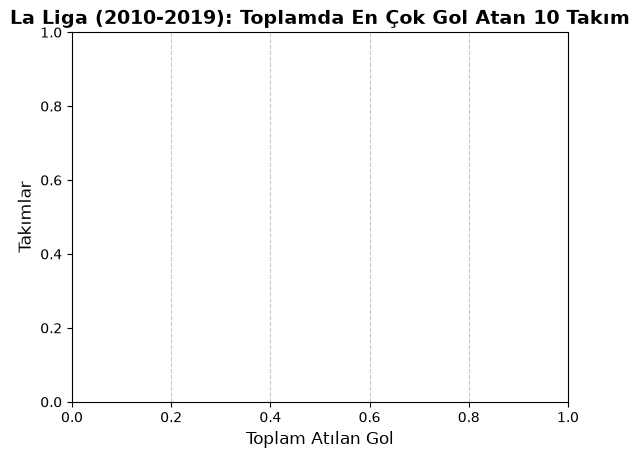

In [73]:
plt.title('La Liga (2010-2019): Toplamda En Çok Gol Atan 10 Takım', fontsize=14, fontweight='bold')
plt.xlabel('Toplam Atılan Gol', fontsize=12)
plt.ylabel('Takımlar', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

In [74]:
plt.show()

<Axes: xlabel='points', ylabel='Count'>

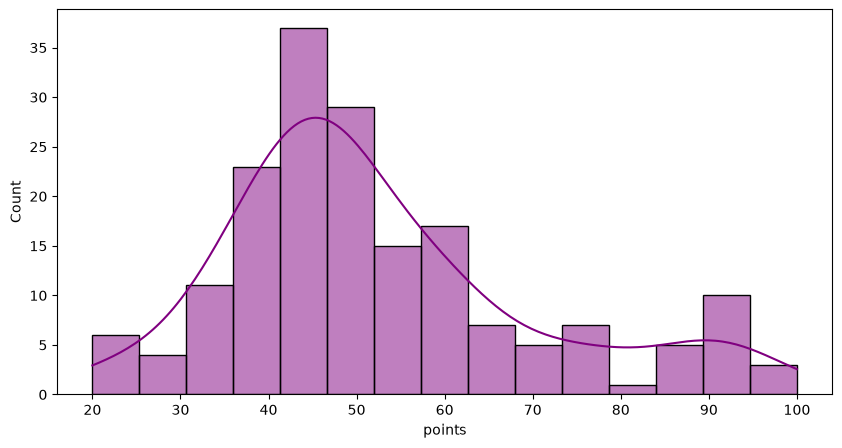

In [75]:
# Görselleştirme Türü 3: Histogram (Puan Dağılımı)
plt.figure(figsize=(10, 5))
sns.histplot(df_proje['points'], bins=15, kde=True, color='purple')

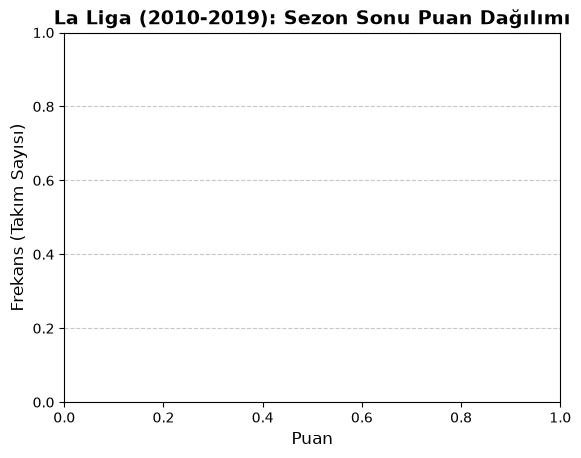

In [76]:
plt.title('La Liga (2010-2019): Sezon Sonu Puan Dağılımı', fontsize=14, fontweight='bold')
plt.xlabel('Puan', fontsize=12)
plt.ylabel('Frekans (Takım Sayısı)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

In [77]:
plt.show()

In [78]:
# Görselleştirme Türü 4: Korelasyon Isı Haritası (Değişkenler arası ilişki gücü)
plt.figure(figsize=(8, 6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [79]:
# Sadece ilgilendiğimiz sayısal sütunları seçiyoruz
korelasyon_degiskenleri = df_proje[['points', 'wins', 'goals_for', 'goals_against']]

<Axes: >

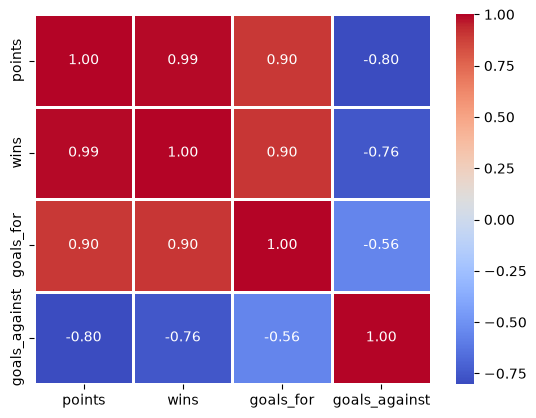

In [80]:
# Isı haritasını çizdiriyoruz
sns.heatmap(korelasyon_degiskenleri.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=1)

Text(0.5, 1.0, 'Önemli Metriklerin Korelasyon Isı Haritası')

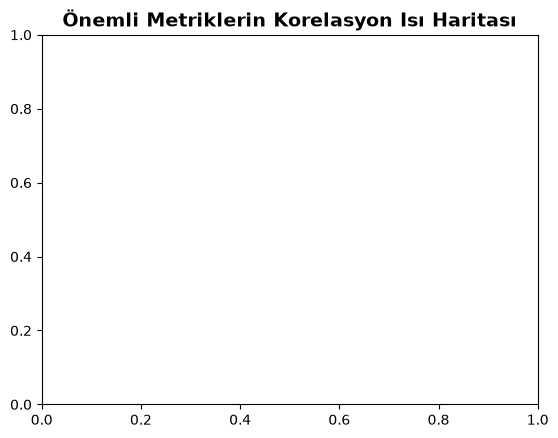

In [81]:
plt.title('Önemli Metriklerin Korelasyon Isı Haritası', fontsize=14, fontweight='bold')

In [82]:
plt.show()

In [83]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [84]:
# 1. Özellikler (X) ve Hedef Değişken (y) Belirleme
# X: Neleri kullanarak tahmin yapacağız? (Atılan ve Yenilen Goller)
# y: Neyi tahmin etmeye çalışıyoruz? (Puan)
X = df_proje[['goals_for', 'goals_against']]
y = df_proje['points']

In [85]:
# 2. Veriyi Eğitim (%80) ve Test (%20) Olarak İkiye Bölme
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [86]:
# 3. Modeli Kurma ve Eğitme (Yapay Zeka burada öğreniyor)
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ 0.54,-0.59]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['goals_for','goals_against']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,55.16
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [87]:
# 4. Eğitilmiş Model ile Test Verisi Üzerinde Tahmin Yapma
y_pred = model.predict(X_test)

In [88]:
# 5. Modelin Başarısını Ölçme
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

In [89]:
print("--- Makine Öğrenmesi Model Sonuçları ---")
print(f"Modelin R-kare Skoru (Açıklanabilirlik): {r2:.3f}")
print(f"Hata Payı (MSE): {mse:.2f}")

--- Makine Öğrenmesi Model Sonuçları ---
Modelin R-kare Skoru (Açıklanabilirlik): 0.928
Hata Payı (MSE): 21.53


In [90]:
# Eğlenceli bir test: Modelin bulduğu formüle göre atılan ve yenilen golün puan üzerindeki etkisi
print("\n--- Modelin Çıkardığı Formül ---")
print(f"Her 1 Atılan Golün Puana Etkisi: +{model.coef_[0]:.2f} Puan")
print(f"Her 1 Yenilen Golün Puana Etkisi: {model.coef_[1]:.2f} Puan")


--- Modelin Çıkardığı Formül ---
Her 1 Atılan Golün Puana Etkisi: +0.54 Puan
Her 1 Yenilen Golün Puana Etkisi: -0.59 Puan


In [91]:
# Özellik Mühendisliği (Feature Engineering) - Yeni Sütun Üretme
# Gol Oranı = Atılan Gol / Yenilen Gol 
# (Sonucu daha okunaklı yapmak için round() ile virgülden sonra 2 basamağa yuvarlıyoruz)

df_proje['goal_ratio'] = round(df_proje['goals_for'] / df_proje['goals_against'], 2)

In [92]:
print("--- Veri Setine Yeni Eklenen 'goal_ratio' (Gol Oranı) Sütunu ---")
# Sadece ilgili sütunları seçip ilk 5 satırı (head) gösteriyoruz
display(df_proje[['squad', 'goals_for', 'goals_against', 'goal_ratio']].head())

--- Veri Setine Yeni Eklenen 'goal_ratio' (Gol Oranı) Sütunu ---


,squad,goals_for,goals_against,goal_ratio
858,Barcelona,95,21,4.52
859,Real Madrid,102,33,3.09
860,Valencia,64,44,1.45
861,Villarreal,54,44,1.23
862,Sevilla,62,61,1.02


In [93]:
# Detaylı İstatistiksel Analiz (Gruplama)
# Takımlara göre gruplayıp, ilgilendiğimiz sütunların ortalamasını alıyoruz
ozet_tablo = df_proje.groupby('squad')[['points', 'goals_for', 'goals_against']].mean()

In [94]:
# Puan ortalamasına göre büyükten küçüğe sıralayıp ilk 5 takımı alıyoruz
en_iyi_5 = ozet_tablo.sort_values(by='points', ascending=False).head(5)

In [95]:
# Rakamların okunabilir olması için virgülden sonra 2 basamağa yuvarlıyoruz
en_iyi_5 = en_iyi_5.round(2)

In [96]:
print("--- La Liga (2010-2019) Sezon Başına Ortalama Performans (İlk 5 Takım) ---")
display(en_iyi_5)

--- La Liga (2010-2019) Sezon Başına Ortalama Performans (İlk 5 Takım) ---


,points,goals_for,goals_against
squad,,,
Barcelona,92.11,105.67,30.56
Real Madrid,87.00,102.33,38.67
Atlético Madrid,75.44,63.33,31.22
Valencia,60.78,58.78,45.89
Sevilla,59.78,59.89,51.44


In [97]:
# Final: Temizlenmiş ve İşlenmiş Veriyi Dışa Aktarma (Kaydetme)
# index=False parametresi, satır numaralarının veriye dahil olmasını engeller (daha temiz görünür)
dosya_adi = 'laliga_temiz_veri.csv'
df_proje.to_csv(dosya_adi, index=False)

In [98]:
print(f"--- TEBRİKLER! ---")
print(f"Temizlenmiş veri seti başarıyla '{dosya_adi}' adıyla kaydedildi.")
print(f"Toplam Satır: {df_proje.shape[0]}, Toplam Sütun: {df_proje.shape[1]}")

--- TEBRİKLER! ---
Temizlenmiş veri seti başarıyla 'laliga_temiz_veri.csv' adıyla kaydedildi.
Toplam Satır: 180, Toplam Sütun: 28
